In [2426]:
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
import pandas as pd

<h2>Review </h2>

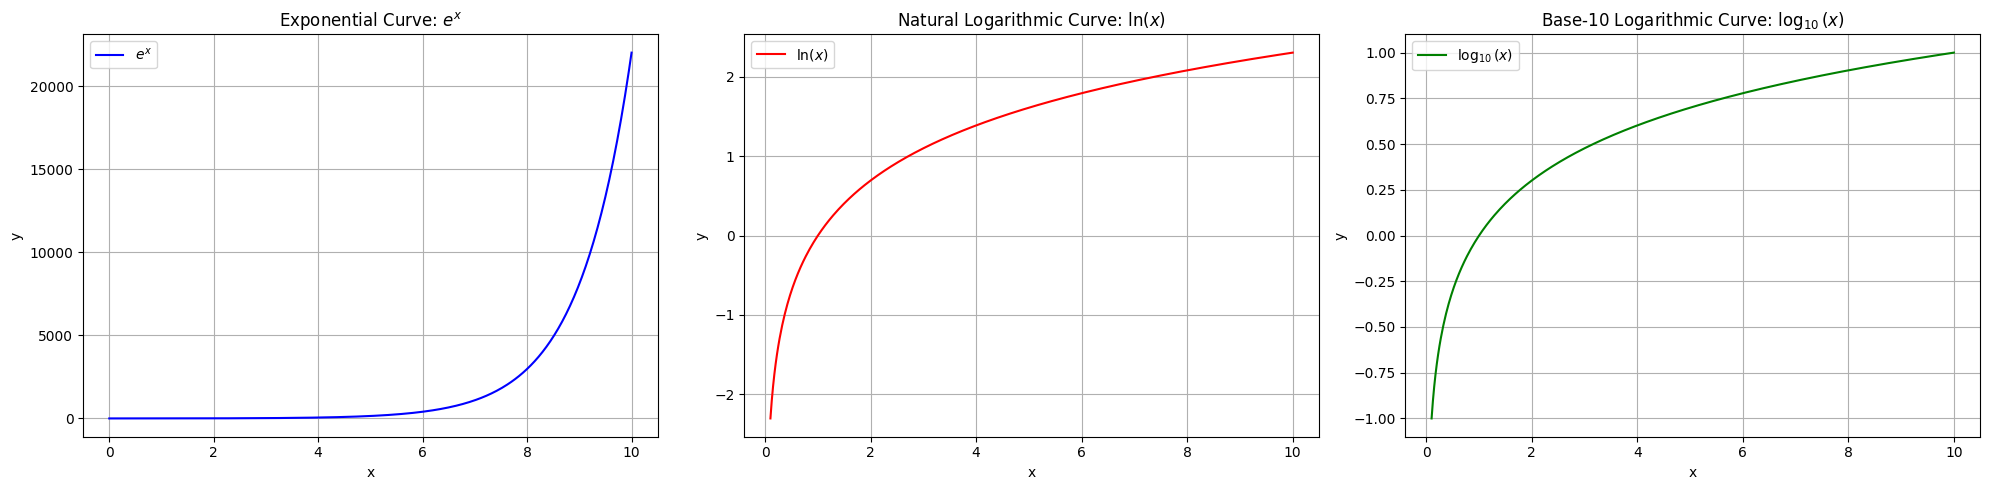

In [ ]:
x_exp = np.linspace(0, 10, 400)  
x_log = np.linspace(0.1, 10, 400)  

y_exp = np.exp(x_exp)       
y_ln = np.log(x_log)        
y_log10 = np.log10(x_log)  

fig, axs = plt.subplots(1, 3, figsize=(20, 5))

axs[0].plot(x_exp, y_exp, label=r'$e^x$', color='blue')
axs[0].set_title('Exponential Curve: $e^x$')
axs[0].set_xlabel('x')
axs[0].set_ylabel('y')
axs[0].grid(True)
axs[0].legend()

axs[1].plot(x_log, y_ln, label=r'$\ln(x)$', color='red')
axs[1].set_title('Natural Logarithmic Curve: $\ln(x)$')
axs[1].set_xlabel('x')
axs[1].set_ylabel('y')
axs[1].grid(True)
axs[1].legend()

axs[2].plot(x_log, y_log10, label=r'$\log_{10}(x)$', color='green')
axs[2].set_title('Base-10 Logarithmic Curve: $\log_{10}(x)$')
axs[2].set_xlabel('x')
axs[2].set_ylabel('y')
axs[2].grid(True)
axs[2].legend()


plt.tight_layout()

plt.show()


<h2> note </h2>
<h4>log(0) and ln(0) not define </h4>
<h4>exp(0) = 1 </h4>

In [2428]:
def perform_adf_test(series):
    result = adfuller(series)
    print('ADF Statistic: %f' % result[0])
    print('p-value: %f' % result[1])

<h2>Original Series </h2>

In [2429]:
ts = pd.read_csv('original_series')
ts.head()

,0
0,956.438486
1,7284.907174
2,11357.870166
3,13622.652007
4,17137.455304


In [2430]:
ts.index = np.arange(1,len(ts)+1)

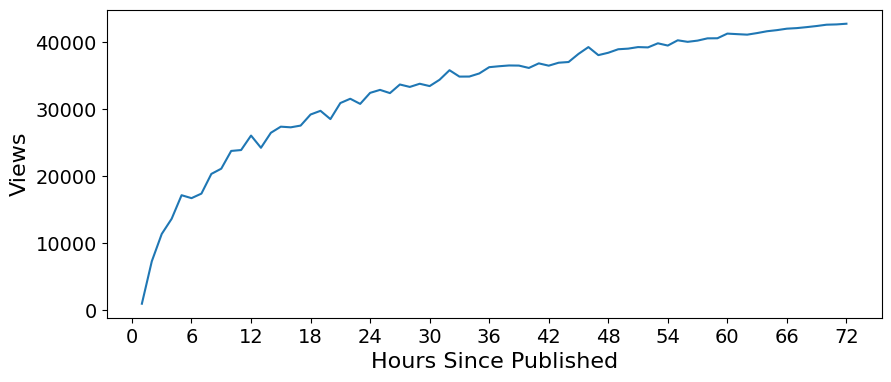

In [2431]:
plt.figure(figsize=(10,4))
plt.plot(ts)
plt.xticks(np.arange(0,78,6), fontsize=14)
plt.xlabel('Hours Since Published', fontsize=16)
plt.yticks(np.arange(0,50000,10000), fontsize=14)
plt.ylabel('Views', fontsize=16)
plt.show()

<h2>Original Series:</h2>

$$
\upsilon_{t}
$$

<h3> 1.Normalize:</h3>

$$
(v_{t}\rightarrow n_{t}):n_{t} =\boxed{\frac{v_{t}-\mu}{\sigma}}

<h3 style="text-align:center">Transform y for improve performence</h3>

<h3>2.Exponentiate:</h3>

$$
(n_{t}\rightarrow e_{t}):e_{t} = e^{n_{t}} \Leftrightarrow (n_{t}\rightarrow e_{t}):e_{t} =\boxed{e^{\frac{v_{t}-\mu}{\sigma}}}
$$

<h3 style="text-align:center">Transform from log to linear time  series</h3>

<h3> 3.First Difference: </h3>

$$
(e_{t}\rightarrow d_{t}):d_{t} = \boxed{e_{t}- e_{t-1}}
$$

<h3 style="text-align:center">For eliminate the trend</h3>

<h3> 4.Final Formula</h3>

$$
d_{t}= \boxed{e^{\frac{v_{t}-\mu}{\sigma}}-e^{\frac{v_{t-1}-\mu}{\sigma}}}
$$

<h3>5.Undo Transaformation </h3>

$$
(\overset{\wedge}{d_{t+1}}\rightarrow \overset{\wedge}{v_{t+1}}):\overset{\wedge}{v_{t+1}} = \boxed{\sigma \ln {({\overset{\wedge}{d_{t+1}}+e^{\frac{v_{t}-\mu}{\sigma}})+\mu}}}


$$

<h2> 1.Normalize:  </h2>

In [2432]:
mu = np.mean(ts)
sigma = np.std(ts)

c:\Users\rt\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\_core\fromnumeric.py:3800: FutureWarning: The behavior of DataFrame.std with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return std(axis=axis, dtype=dtype, out=out, ddof=ddof, **kwargs)


In [2433]:
mu

np.float64(33110.675802312355)

In [2434]:
sigma

0    9034.339798
dtype: float64

In [2435]:
norm_ts = (ts - mu) / sigma
norm_ts[:5]

,0
1,-3.559113
2,-2.858623
3,-2.407791
4,-2.157105
5,-1.768056


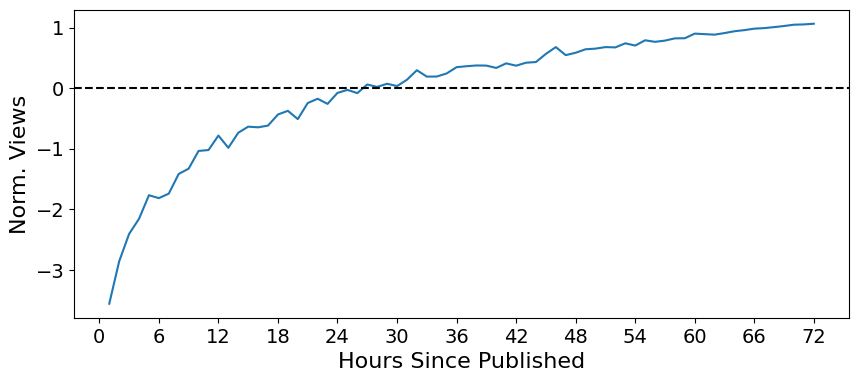

In [2436]:
plt.figure(figsize=(10,4))
plt.plot(norm_ts)
plt.xticks(np.arange(0,78,6), fontsize=14)
plt.xlabel('Hours Since Published', fontsize=16)
plt.yticks(np.arange(-3,2), fontsize=14)
plt.ylabel('Norm. Views', fontsize=16)
plt.axhline(0, color='k', linestyle='--')
plt.show()

<h2>(2) Exponentiate</h2>

In [2437]:
exp_ts = np.exp(norm_ts)
exp_ts[:5]

,0
1,0.028464
2,0.057348
3,0.090014
4,0.115659
5,0.170664


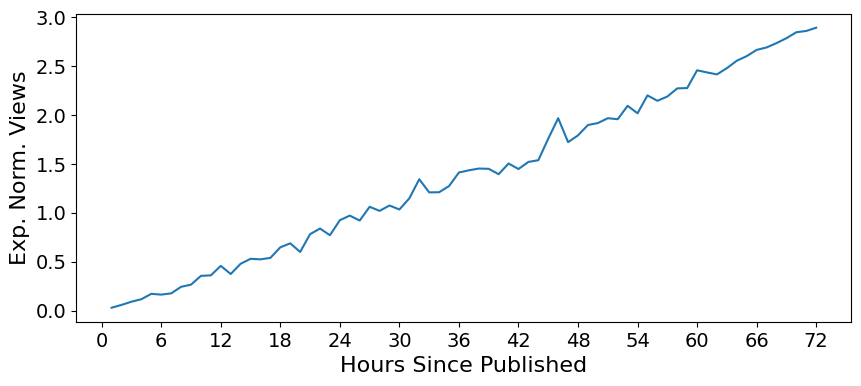

In [2438]:
plt.figure(figsize=(10,4))
plt.plot(exp_ts)
plt.xticks(np.arange(0,78,6), fontsize=14)
plt.xlabel('Hours Since Published', fontsize=16)
plt.yticks(np.arange(0,3.5,.5), fontsize=14)
plt.ylabel('Exp. Norm. Views', fontsize=16)
plt.show()

In [2439]:
perform_adf_test(exp_ts)

ADF Statistic: 1.648979
p-value: 0.997997


<h3>p-value>sig(0.05) mean the time series not stationary</h3> 

<h2>(3) First Difference:   </h2>

In [2440]:
diff_ts = exp_ts.diff().dropna()
diff_ts[:5]

,0
2,0.028884
3,0.032666
4,0.025646
5,0.055005
6,-0.008073


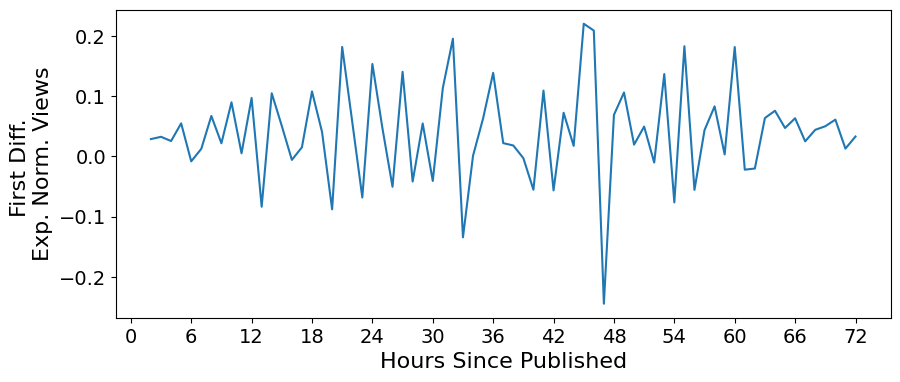

In [2441]:
plt.figure(figsize=(10,4))
plt.plot(diff_ts)
plt.xticks(np.arange(0,78,6), fontsize=14)
plt.xlabel('Hours Since Published', fontsize=16)
plt.yticks(np.arange(-0.2,0.3,.1), fontsize=14)
plt.ylabel('First Diff. \nExp. Norm. Views', fontsize=16)
plt.show()

In [2442]:
perform_adf_test(diff_ts)

ADF Statistic: -4.881064
p-value: 0.000038


<h3>p-value<0.05(sig) mean the time series stationary</h3> 

<h2>Fit AR Model</h2>

<h4>find AR order using PACF </h4>

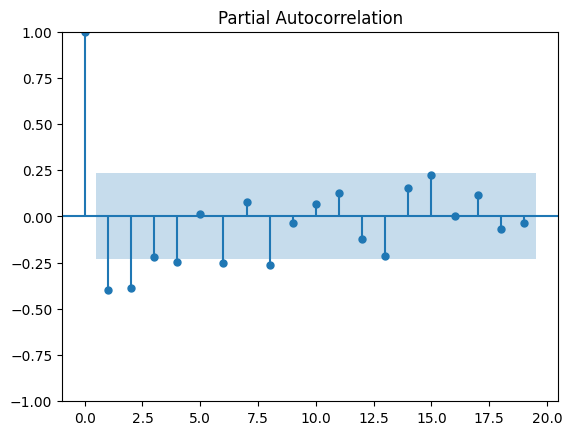

In [2443]:
plot_pacf(diff_ts)
plt.show()

<h4>we see that 4 is the best order auto regression compoment</h4>

<h4>find MA order using ACF </h4>

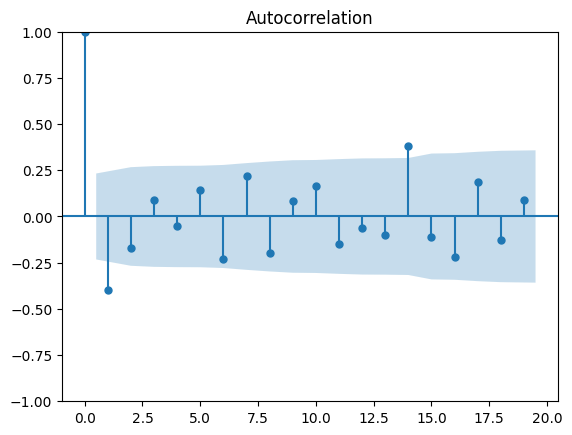

In [2444]:
plot_acf(diff_ts)
plt.show()

<h4>we see that 1 is the best order moving average compoment</h4>

In [2445]:
#create the model
model = ARIMA(diff_ts, order=(4,0,1))

c:\Users\rt\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\rt\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\rt\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


In [2446]:
model_fit=model.fit()

<h2> Predict Out 3 Hours </h2>

In [2447]:
prediction_info = model_fit.forecast(3)

c:\Users\rt\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\rt\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


<h2>How the Lower and Upper Bounds Are Calculated  </h2> 

<h4>Prediction±z×Standard Error</h4>
<h4>Lower Bound=Prediction−(z×Standard Error)</h4>
<h4>Upper Bound=Prediction+(z×Standard Error)</h4>


In [2448]:
prediction_info = model_fit.forecast(3)
prediction_info.index = np.arange(0, len(prediction_info)) # change index to start from zero 

c:\Users\rt\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


In [2449]:
predictions = prediction_info[0]
lower_bound = predictions-prediction_info[2]
upper_bound = predictions+prediction_info[2]

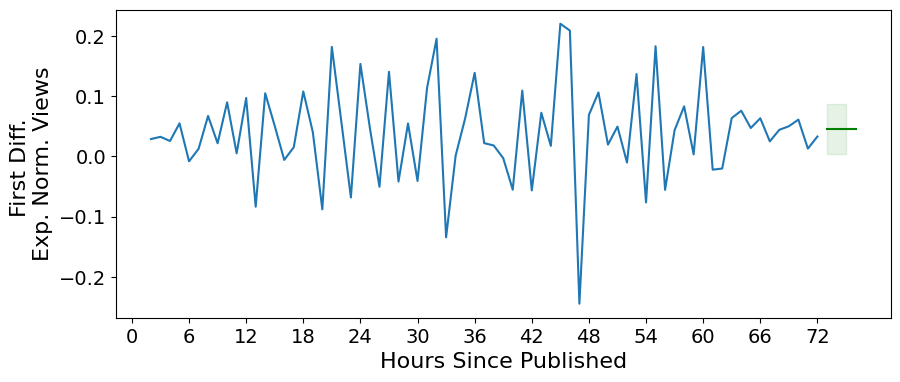

In [2450]:
plt.figure(figsize=(10,4))
plt.plot(diff_ts)
plt.xticks(np.arange(0,78,6), fontsize=14)
plt.xlabel('Hours Since Published', fontsize=16)
plt.yticks(np.arange(-0.2,0.3,.1), fontsize=14)
plt.ylabel('First Diff. \nExp. Norm. Views', fontsize=16)
plt.plot(np.arange(len(ts)+1, len(ts)+5), [predictions for i in range(4) ], color='g')
plt.fill_between(np.arange(len(ts)+1, len(ts)+4), lower_bound, upper_bound, color='g', alpha=0.1)
plt.show()

In [2451]:
def undo_transformations(predictions, series, mu, sigma):
    predictions=[predictions]
    first_pred = sigma*np.log(predictions[0] + np.exp((series.iloc[-1]-mu)/sigma)) + mu
    orig_predictions = [first_pred]
    
    for i in range(len(predictions[1:])):
        next_pred = sigma*np.log(predictions[i+1] + np.exp((orig_predictions[-1]-mu)/sigma)) + mu
        orig_predictions.append(next_pred)
    
    return np.array(orig_predictions).flatten()

In [2452]:
orig_preds = undo_transformations(predictions, ts, mu, sigma)
orig_lower_bound = predictions-undo_transformations(lower_bound, ts, mu, sigma)
orig_upper_bound = predictions+undo_transformations(upper_bound, ts, mu, sigma)

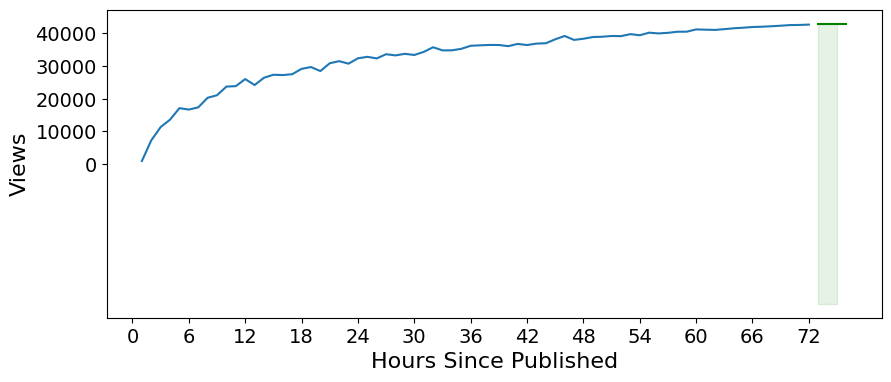

In [2453]:
plt.figure(figsize=(10,4))
plt.plot(ts)
plt.xticks(np.arange(0,78,6), fontsize=14)
plt.xlabel('Hours Since Published', fontsize=16)
plt.yticks(np.arange(0,50000,10000), fontsize=14)
plt.ylabel('Views', fontsize=16)
plt.plot(np.arange(len(ts)+1, len(ts)+5), [orig_preds for i in range(4) ], color='g')
plt.fill_between(np.arange(len(ts)+1, len(ts)+4), orig_lower_bound, orig_upper_bound, color='g', alpha=0.1)
plt.show()

(40000.0, 45000.0)

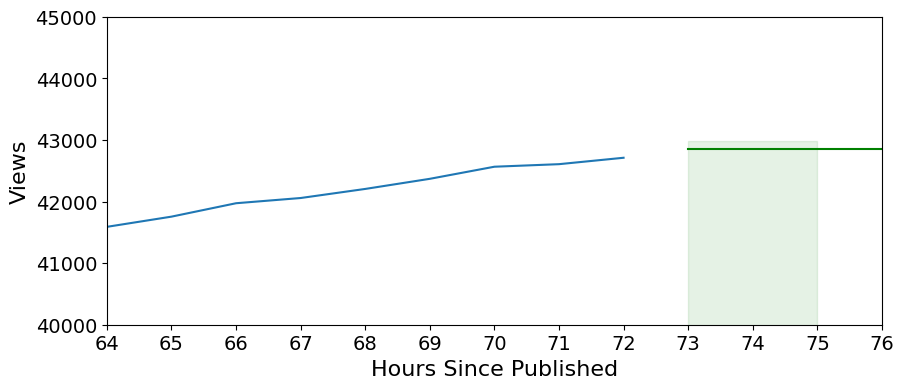

In [2454]:
plt.figure(figsize=(10,4))
plt.plot(ts)
plt.xticks(np.arange(0,78), fontsize=14)
plt.xlabel('Hours Since Published', fontsize=16)
plt.yticks(np.arange(40000,46000,1000), fontsize=14)
plt.ylabel('Views', fontsize=16)
plt.plot(np.arange(len(ts)+1, len(ts)+5), [orig_preds for i in range(4) ], color='g')
plt.fill_between(np.arange(len(ts)+1, len(ts)+4), orig_lower_bound, orig_upper_bound, color='g', alpha=0.1)
plt.xlim(64,76)
plt.ylim(40000, 45000)